In [20]:
from PINN_XWave_DDP import *

In [21]:
#Global variables physics constants
vth = .1
omega_ce = 2.
omega = 2.5
omega_pe = 1.0
phi_amp = 1.


k, k_lambda_D = dispersion(omega, omega_ce, omega_pe, vth)
print(f"k = {k:.3f}, k*lambda_D = {k_lambda_D:.3f}")

omega_list = [omega]
phi_amp_list = [phi_amp]  # Amplitude of the electric field
delta_list = [0.0]  # Phase factor for the wave solution

lamda = 2 * np.pi / k  # Wavelength
T = (2 * np.pi) / omega  # Period of the wave
xmin, xmax = 0, 3*lamda
tmin, tmax = 0, 3*T

L = xmax - xmin  # Length of the domain
tau = tmax - tmin  # Time duration of the wave
Nt = 2000 # Number of time points
Nx = 2000 # Number of spatial points
Nt_coll = 200 
Nx_coll = 200
dt = T/float(Nt)
dx = L/float(Nx)

t_arr = np.linspace(tmin, tmax, Nt)
x_arr = np.linspace(xmin, xmax, Nx)

print(f"k = {k:.4e}")
print(f"k lambda_debye = {k_lambda_D:.4e}")
print(f"L = {L:.3e} [c / omega_pe]")
print(f"T = {T:.3e} [1 / omega_pe]")
print(f"dx = {dx:.3e} [c / omega_pe]")
print(f"dt = {dt:.3e} [1 / omega_pe]")

X_arr, T_arr, phi_flat, Bdot_flat, Ax_flat, Ay_flat, Vx_flat, Vy_flat, N_flat, = generate_data(xmin = xmin, xmax = xmax, tmin = tmin, tmax = tmax, nx = Nx, nt = Nt, vth=vth,
                                                                                                omega_ce = omega_ce, omega_pe = omega_pe, omega_list = omega_list, phi_amp_list=phi_amp_list,
                                                                                                delta_list=delta_list)

x_sparse, t_sparse, phi_sparse, Bdot_sparse = sparse_measurements(X_arr, T_arr, phi_flat, Bdot_flat, num_samples=500)

x_coll, t_coll, dx, dt = collocation_points(xmin, xmax, tmin, tmax, Nx_coll, Nt_coll, L, tau)

k = 1.432, k*lambda_D = 0.143
k = 1.4318e+00
k lambda_debye = 1.4318e-01
L = 1.317e+01 [c / omega_pe]
T = 2.513e+00 [1 / omega_pe]
dx = 6.583e-03 [c / omega_pe]
dt = 1.257e-03 [1 / omega_pe]


<>:5: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_2355201/2645875149.py:5: SyntaxWarning: invalid escape sequence '\p'
  titles_GT = [f'$\phi [\\frac{{m_{{e}}c^2}}{{e}}]$',
/tmp/ipykernel_2355201/2645875149.py:6: SyntaxWarning: invalid escape sequence '\d'
  f'$\dot{{B}} [\\frac{{e}}{{m_{{e}}c}}]$',


-------Plotting Ground Truth Values-------------


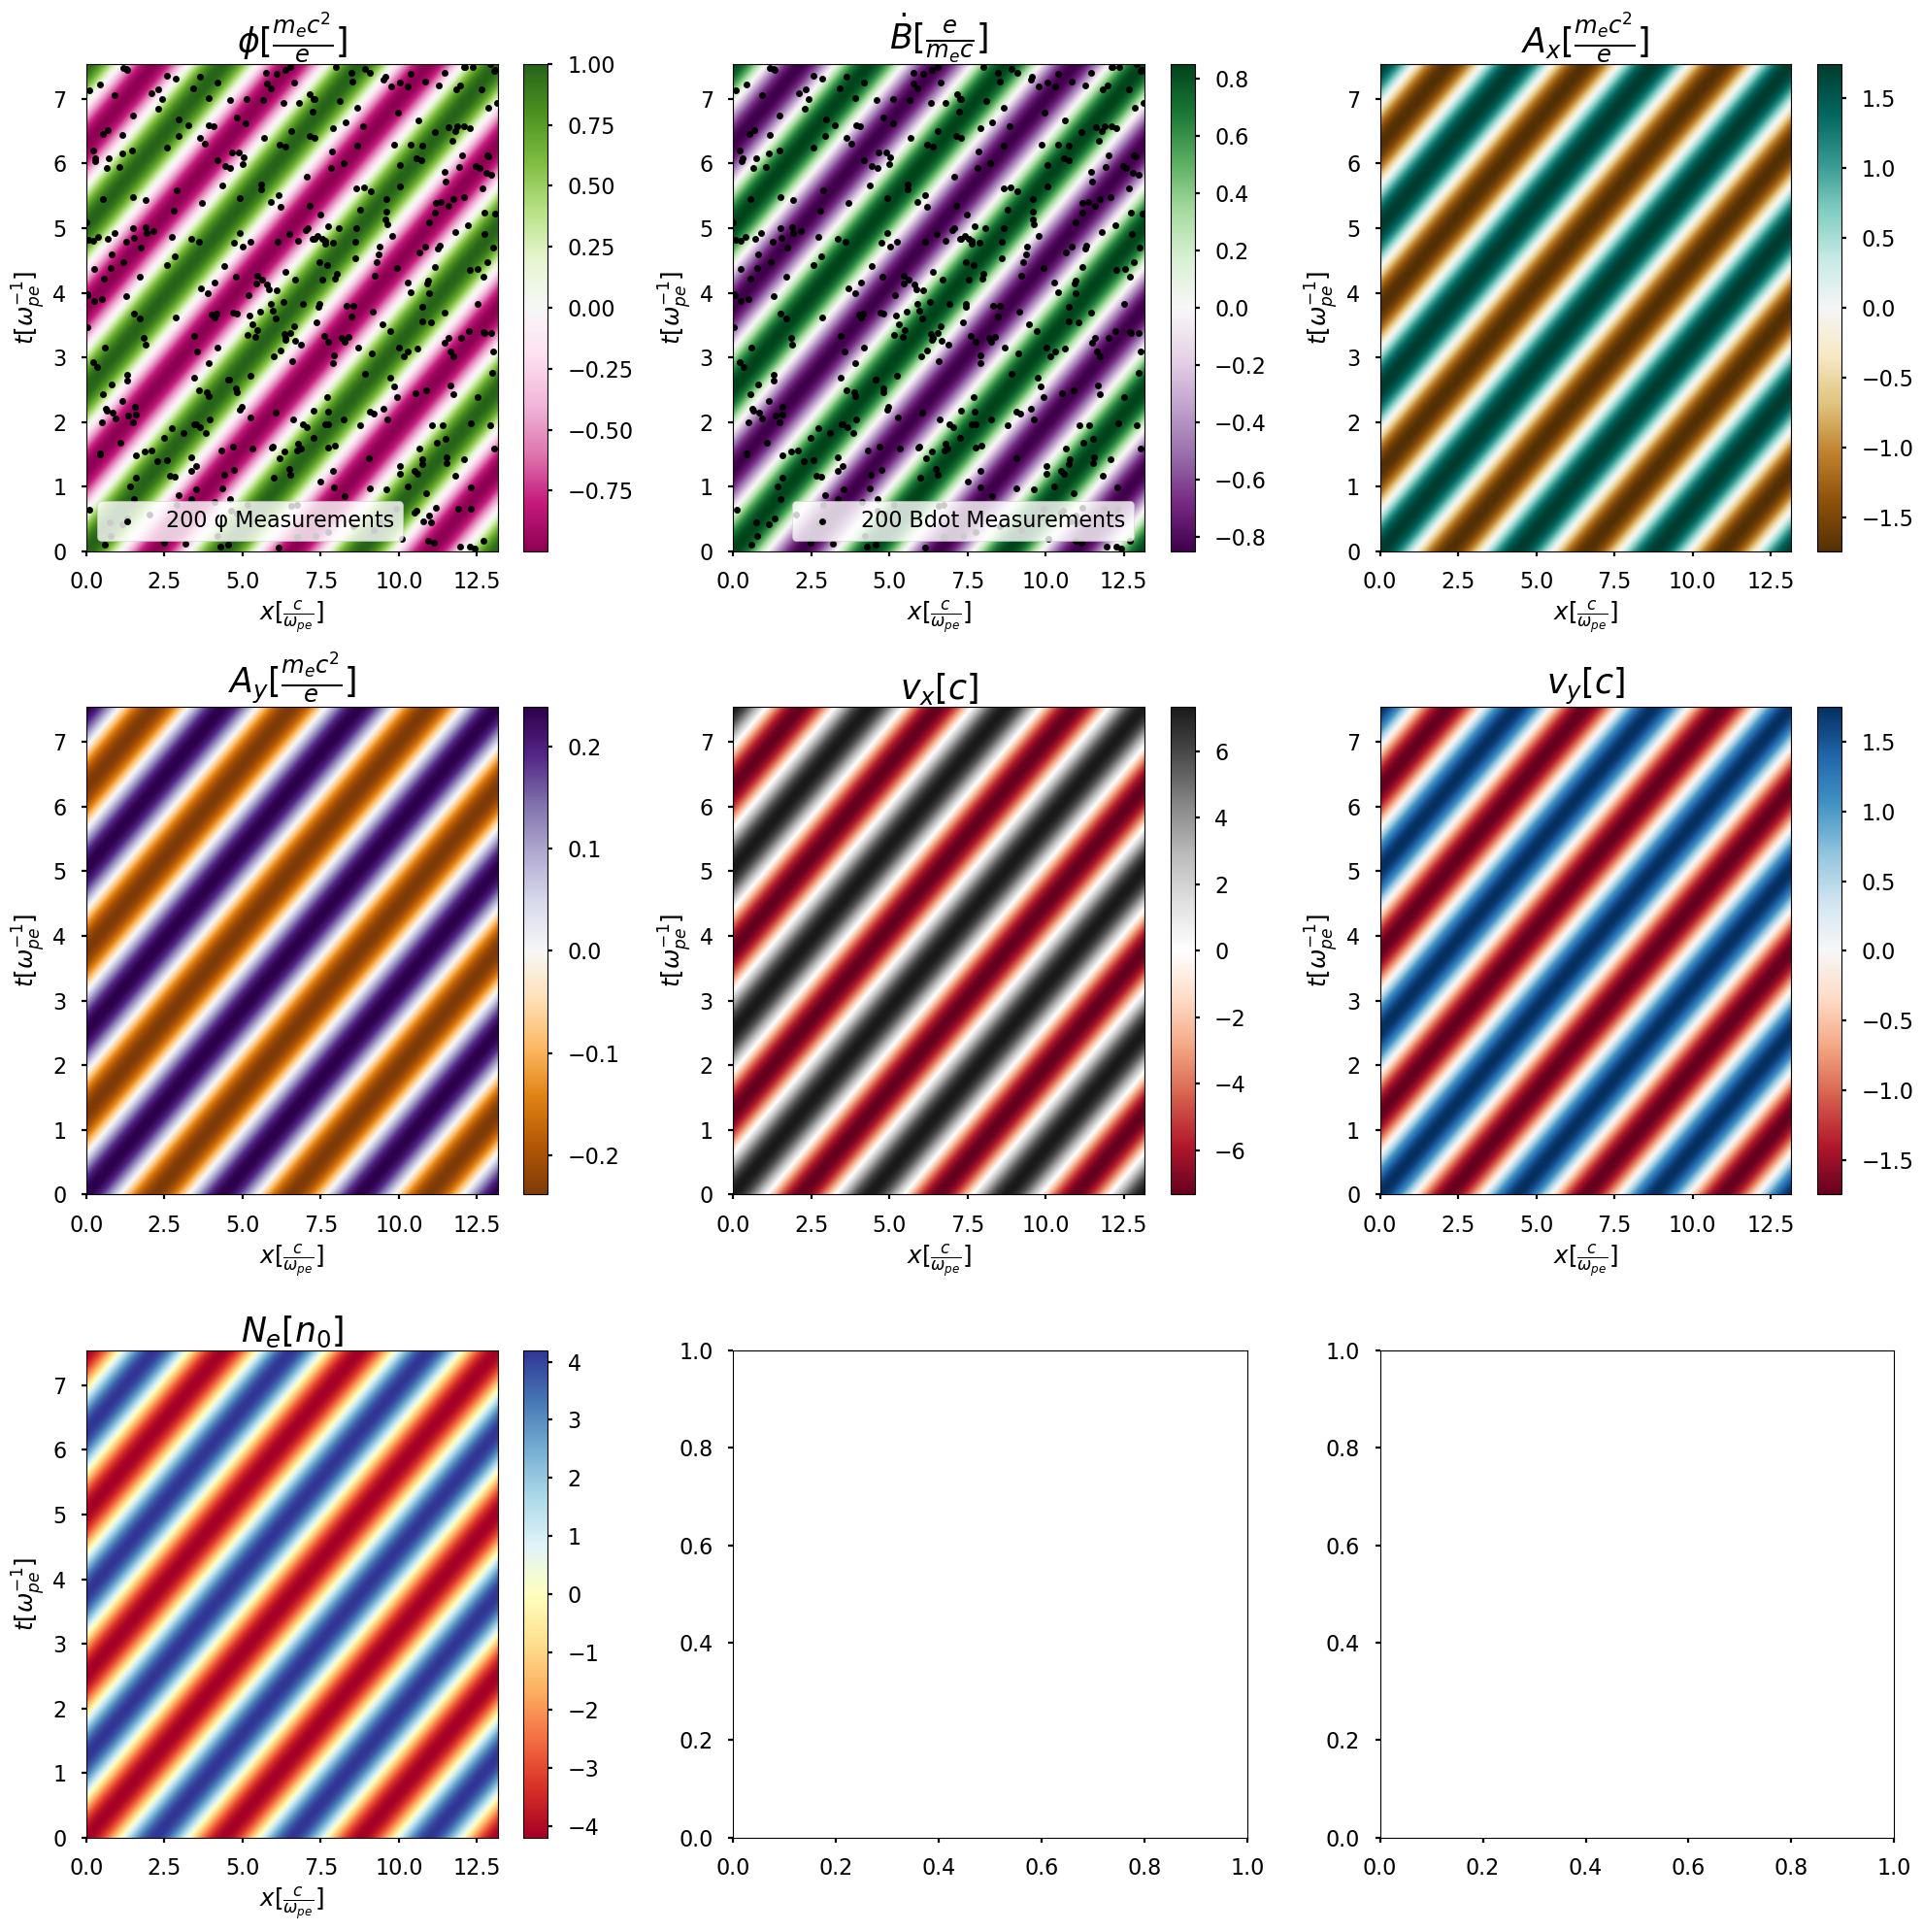

<Figure size 1280x880 with 0 Axes>

In [22]:
quantities_flat = [phi_flat, Bdot_flat, Ax_flat, Ay_flat, Vx_flat, Vy_flat, N_flat]
extent_GT = [xmin, xmax, tmin, tmax]
quantities_GT = [x.reshape(Nt, Nx) for x in quantities_flat]
sparse = [x_sparse, t_sparse, phi_sparse, Bdot_sparse]
titles_GT = [f'$\phi [\\frac{{m_{{e}}c^2}}{{e}}]$', 
            f'$\dot{{B}} [\\frac{{e}}{{m_{{e}}c}}]$',
            f'$A_x [\\frac{{m_{{e}}c^2}}{{e}}]$',
            f'$A_y [\\frac{{m_{{e}}c^2}}{{e}}]$',
            f'$v_x [c]$', 
            f'$v_y [c]$', 
            f'$N_e [n_0]$']

#Plot Ground Truth Values
print("-------Plotting Ground Truth Values-------------")
plot_analytical(quantities=quantities_GT, sparse = sparse, titles = titles_GT, extent = extent_GT)

In [24]:
print("dx = ", dx)
print("dt = ", dt)

dx =  0.06615628601711317
dt =  0.03788855461615831


In [ ]:
#Plot constraints
phi = quantities_GT[0]
Bdot= quantities_GT[1]
Ax = quantities_GT[2]
Ay = quantities_GT[3]
Vx = quantities_GT[4]
Vy = quantities_GT[5]
N = quantities_GT[6]


phi_x = derivative_x(phi, dx)
phi_xx = derivative_xx(phi, dx)
phi_t = derivative_t(phi, dt)
phi_tt = derivative_tt(phi, dt)
phi_xt = derivative_xt(phi, dx=dx, dt=dt)

Ax_x = derivative_x(Ax, dx)
Ax_xx = derivative_xx(Ax, dx)
Ax_t = derivative_t(Ax, dt)
Ax_tt = derivative_tt(Ax, dt)
Ax_xt = derivative_xt(Ax_x, dx=dx, dt=dt)
Ay_x = derivative_x(Ay, dx)
Ay_xx = derivative_xx(Ay, dx)
Ay_t = derivative_t(Ay, dt)
Ay_tt = derivative_tt(Ay, dt)
Ay_xt = derivative_xt(Ay_x, dx=dx, dt=dt)

Vx_x = derivative_x(Vx, dx)
Vx_t = derivative_t(Vx, dt)
Vy_x = derivative_x(Vy, dx)
Vy_t = derivative_t(Vy, dt)

N_t = derivative_t(N, dt)


gauge = Ax_x + phi_t             #Gauge
maxwell_1x = phi_xx + Ax_xt + N       #Maxwell_1x
maxwell_2x = Ax_tt - phi_xt + Vx      #Maxwell_2x
# maxwell_2y = -Ay_xx + Ay_tt + Vy      #Maxwell_2y
wave_Ax = Ax_xx - Ax_tt - Vx       #Wave_Ax
wave_Ay = Ay_xx - Ay_tt - Vy       #Wave_Ay  
wave_phi = phi_xx - phi_tt + N      #Wave_phi 
bdot_curlA = Bdot - Ay_xt             #B_curl(A)
momentum_x = Vx_t - (Vx_x*Ax + Ax_x*Vx + Vy_x*Ay + Vy*Ay_x) - Vx_t      
# momentum_y = Vy_t - Ay_t - Vx*B0_amp      #Momentum_y
continuity = N_t + Vx_x  

constraints_ext = [x_arr[1], x_arr[-2], t_arr[1], t_arr[-2]]
constraints = [gauge, maxwell_1x, maxwell_2x,
               wave_Ax, wave_Ay, wave_phi, bdot_curlA,
               momentum_x, continuity]
constraint_titles = [r'$|\partial_x A_x + \partial_t \phi|$', 
          r'$|\partial_{xx}^2 \phi + \partial_{xt}^2 A_x + N_e|$',
          r'$|\partial_{tt}^2 A_x - \partial_{xt}^2 \phi + V_x|$',
          r'$|\partial_{xx}^2 A_x - \partial_{tt}^2 A_x - V_x|$',
          r'$|\partial_{xx}^2 A_y - \partial_{tt}^2 A_y - V_y|$',
          r'$|\partial_{xx}^2 \phi - \partial_{tt}^2 \phi + N_e|$',
          r'$|\dot{B} - \partial_{tx}^2 A_y|$',
          r'$|\partial_x \phi - \partial_x(V_x A_x + V_y A_y) - \partial_t V_x|$',
          r'$|\partial_t N_e + \partial_x V_x|$']
plot_constraints(constraints=constraints, titles=constraint_titles, extent = constraints_ext)

TypeError: unsupported operand type(s) for -: 'list' and 'list'

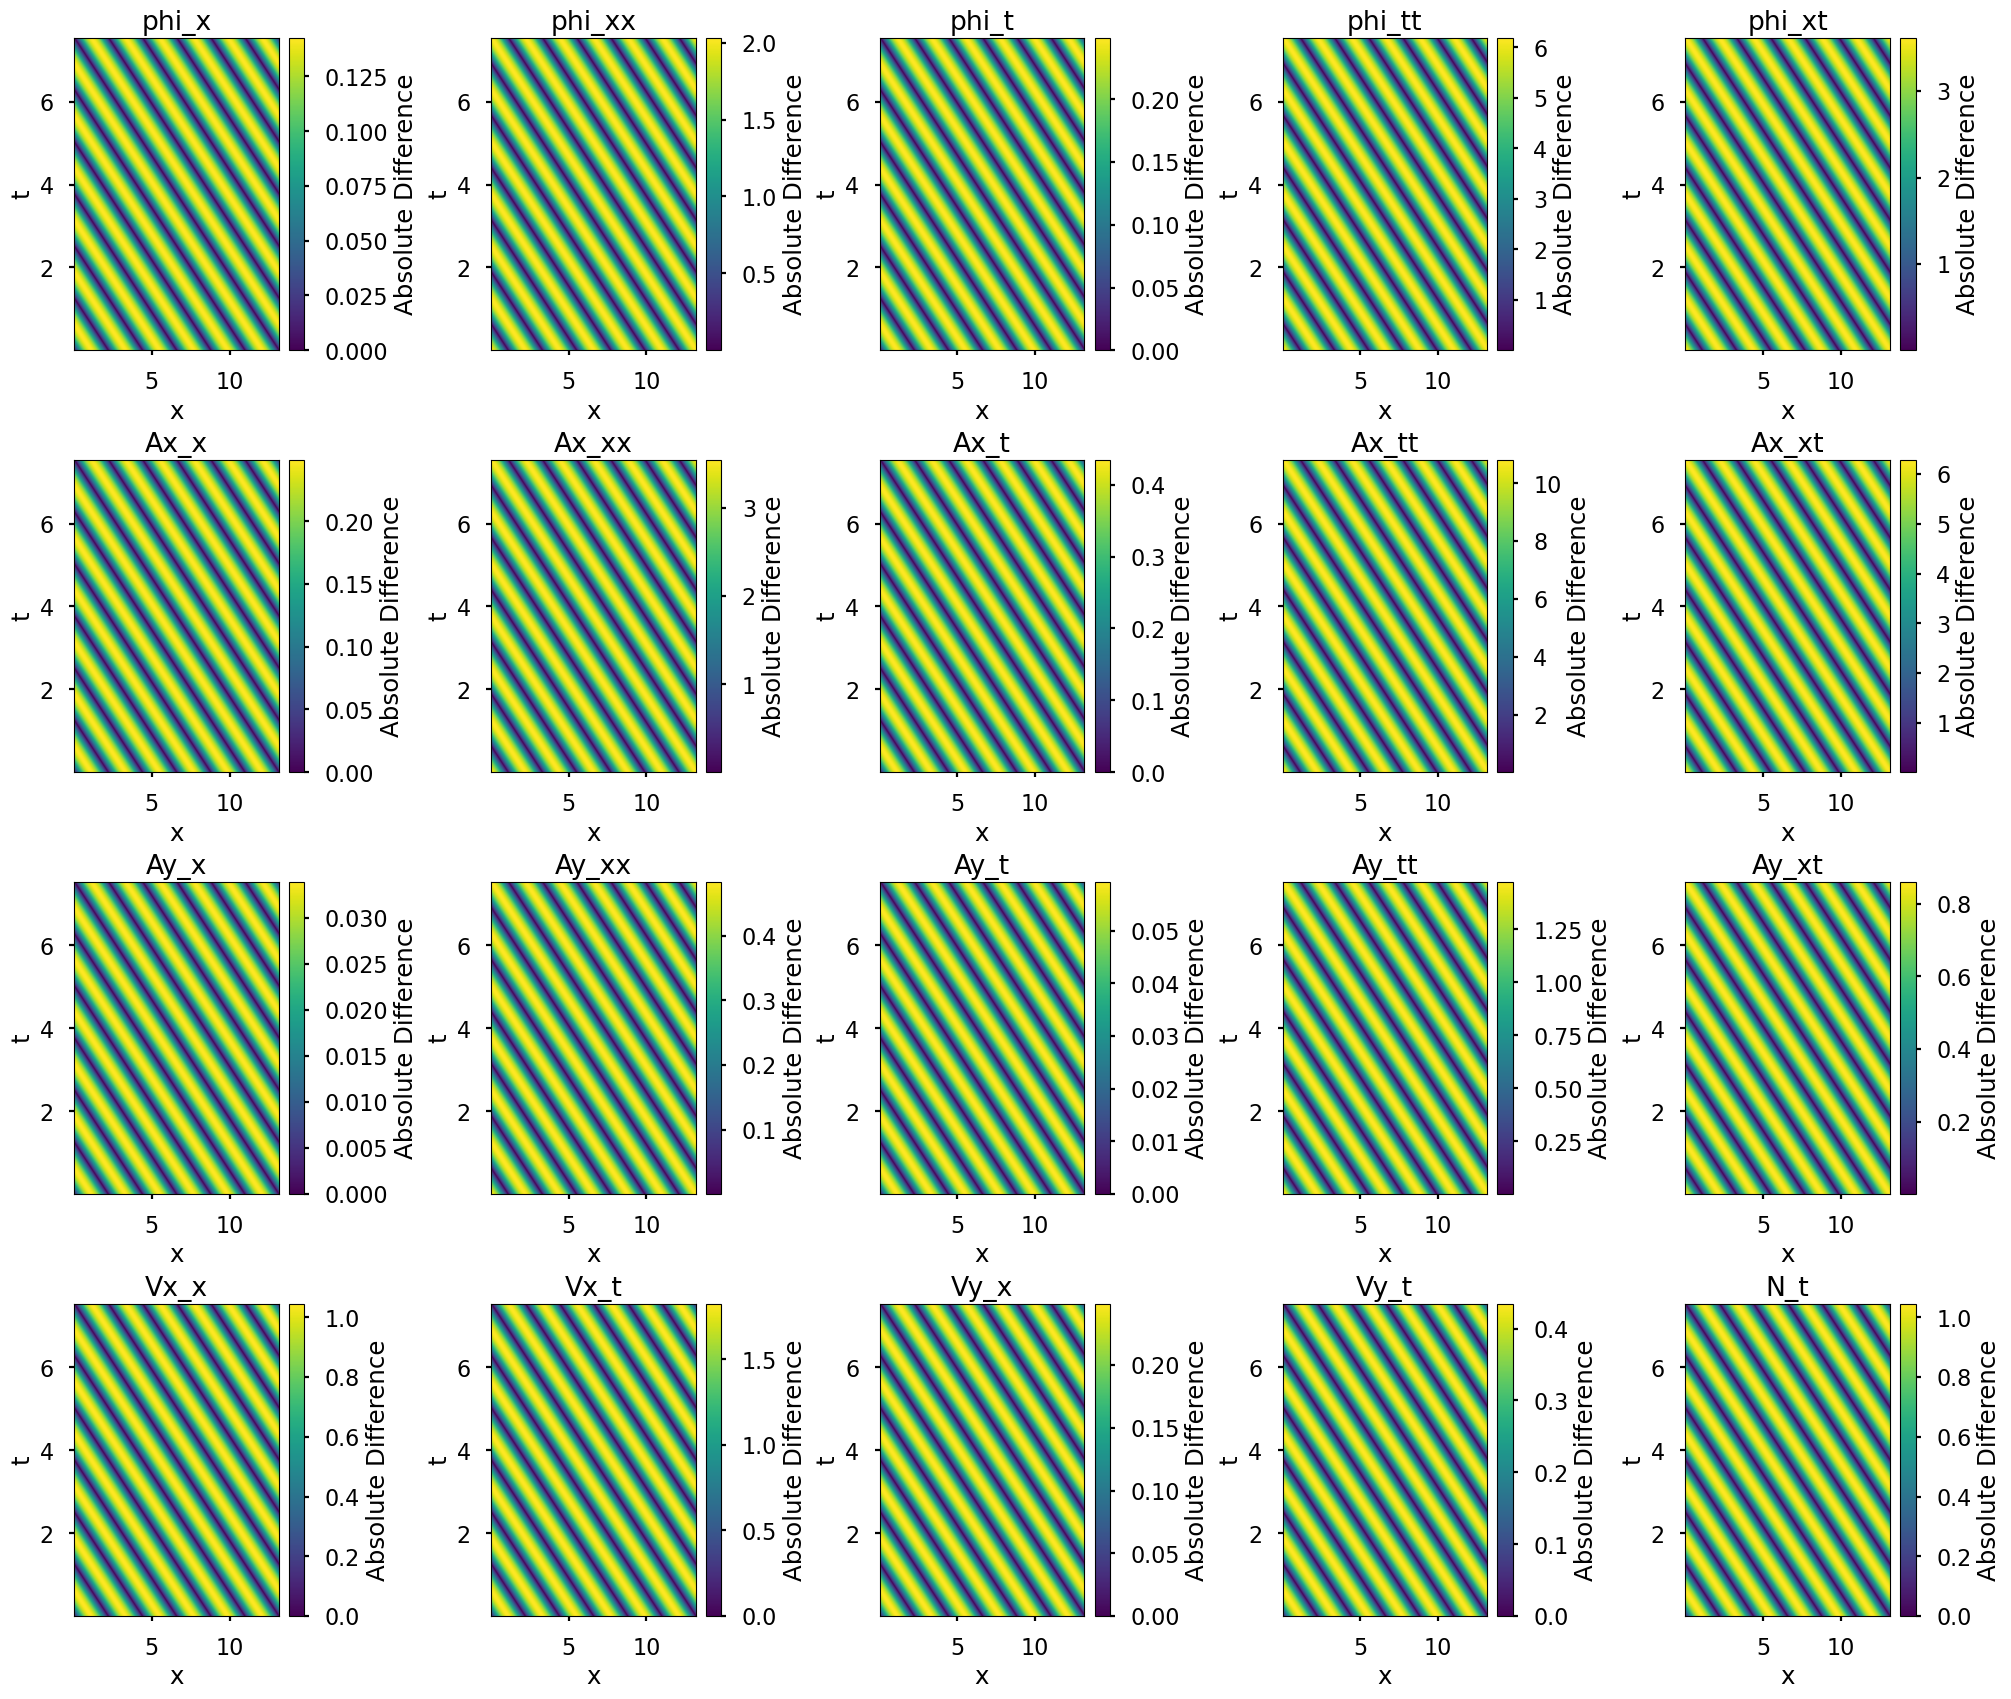

In [ ]:
phi = quantities_GT[0]
Bdot= quantities_GT[1]
Ax = quantities_GT[2]
Ay = quantities_GT[3]
Vx = quantities_GT[4]
Vy = quantities_GT[5]
N = quantities_GT[6]


#Numerical Derivatives
# phi_x = derivative_x(phi, dx)
# phi_xx = derivative_x(phi_x, dx)
# phi_t = derivative_t(phi, dt)
# phi_tt = derivative_t(phi_t, dt)
# phi_xt = derivative_t(phi_x, dt)

# Ax_x = derivative_x(Ax, dx)
# Ax_xx = derivative_x(Ax_x, dx)
# Ax_t = derivative_t(Ax, dt)
# Ax_tt = derivative_t(Ax_t, dt)
# Ax_xt = derivative_t(Ax_x, dx)
# Ay_x = derivative_x(Ay, dx)
# Ay_xx = derivative_x(Ay_x, dx)
# Ay_t = derivative_t(Ay, dt)
# Ay_tt = derivative_t(Ay_t, dt)
# Ay_xt = derivative_t(Ay_x, dt)

# Vx_x = derivative_x(Vx, dx)
# Vx_t = derivative_t(Vx, dt)
# Vy_x = derivative_x(Vy, dx)
# Vy_t = derivative_t(Vy, dt)

# N_t = derivative_t(N, dt)

num_sols = [phi_x, phi_xx, phi_t, phi_tt, phi_xt,
            Ax_x, Ax_xx, Ax_t, Ax_tt, Ax_xt,
            Ay_x, Ay_xx, Ay_t, Ay_tt, Ay_xt,
            Vx_x, Vx_t, Vy_x, Vy_t, N_t]

#analytical derivatives
phi_x_analytical = 1j*k*phi
phi_xx_analytical = -(k**2) * phi
phi_t_analytical = -1j*omega*phi
phi_tt_analytical = -(omega**2) * phi
phi_xt_analytical = omega*k*phi

Ax_x_analytical = 1j*k*Ax
Ax_xx_analytical = -(k**2)*Ax
Ax_t_analytical = -1j*omega*Ax
Ax_tt_analytical = -(omega**2)*Ax
Ax_xt_analytical = omega*k*Ax
Ay_x_analytical = 1j*k*Ay
Ay_xx_analytical = -(k**2)*Ay
Ay_t_analytical = -1j*omega*Ay
Ay_tt_analytical = -(omega**2)*Ay
Ay_xt_analytical = omega*k*Ay

Vx_x_analytical = 1j*k*Vx
Vx_t_analytical = -1j*omega*Vx
Vy_x_analytical = 1j*k*Vy
Vy_t_analytical = -1j*omega*Vy

N_t_analytical = -1j*omega*N

analytical_sols = np.real(np.array([phi_x_analytical, phi_xx_analytical, phi_t_analytical, phi_tt_analytical, phi_xt_analytical,
            Ax_x_analytical, Ax_xx_analytical, Ax_t_analytical, Ax_tt_analytical, Ax_xt_analytical,
            Ay_x_analytical, Ay_xx_analytical, Ay_t_analytical, Ay_tt_analytical, Ay_xt_analytical,
            Vx_x_analytical, Vx_t_analytical, Vy_x_analytical, Vy_t_analytical, N_t_analytical]))

titles_sols = ['phi_x', 'phi_xx', 'phi_t', 'phi_tt', 'phi_xt',
               'Ax_x', 'Ax_xx', 'Ax_t', 'Ax_tt', 'Ax_xt',
               'Ay_x', 'Ay_xx', 'Ay_t', 'Ay_tt', 'Ay_xt',
               'Vx_x', 'Vx_t', 'Vy_x', 'Vy_t', 'N_t']
def compare_derives(analytical_sols, num_sols, titles, extent):
    # This creates a 5x4 grid, so axs is a 2D NumPy array of Axes objects.
    # I've changed it to 2x2 to match the mock data.
     # Create a 5x5 grid to accommodate all 21 derivatives
    fig, axs = plt.subplots(5, 5, figsize=(20, 20), constrained_layout=True)

    # Flatten the axes array to easily iterate
    axs = axs.flatten()

    for i, (analytical, numerical, title) in enumerate(zip(analytical_sols, num_sols, titles)):
        if i < len(axs):
            ax = axs[i]
            # Calculate the absolute difference between the solutions
            difference = np.abs(analytical - numerical)

            # Plot the difference using imshow
            im = ax.imshow(difference, extent=extent, aspect='auto')
            fig.colorbar(im, ax=ax, label='Absolute Difference')

            ax.set_title(title)
            ax.set_xlabel('x')
            ax.set_ylabel('t')

    # Hide any unused subplots
    for j in range(len(analytical_sols), len(axs)):
        fig.delaxes(axs[j])


    plt.show()
compare_derives(analytical_sols, num_sols, titles=titles_sols, extent=constraints_ext)